# Criminal Activity Detector — v3 (Final)
**ResNet50 (frozen) feature cache → BiGRU + Temporal Attention → Normal / Suspicious**

## Fixes applied in each version
| Issue | v1 (original) | v2 | v3 (this file) |
|-------|-------------|-----|----------------|
| Class weights | suspicious weighted 0.68 (**wrong**) | Focal Loss α=0.60 | ✅ same |
| Backbone overfit | Unfroze 17 M params → instant overfit | Frozen backbone | ✅ same |
| Training speed | ~11 s/step | Feature cache | ✅ **batched extraction (~8× faster)** |
| Threshold | Fixed 0.50 | suspicious-only F1 → picked 0.120 (too aggressive) | ✅ **macro F1 → balanced** |
| Custom class serialization | — | Missing `@register_keras_serializable` → **load_model crashes** | ✅ **fixed** |
| `TemporalAttention.get_config()` | — | Incomplete → cloning fails | ✅ **fixed** |
| EarlyStopping patience | — | 15 (wasted 15 epochs after peak) | ✅ **6** |
| Callback metric mismatch | — | EarlyStopping=val_auc, ReduceLR=val_loss | ✅ **both val_auc** |
| Overfitting | — | dropout 0.3/0.5 | ✅ **0.4/0.6** |
| Model loading example | — | Missing | ✅ **Cell 17 added** |

Run every cell top-to-bottom.

In [2]:
# ── Cell 1 · Setup ───────────────────────────────────────────────────────────
import os, subprocess

for ck in ['/kaggle/working/runs/best_model.keras',
           '/kaggle/working/runs/final_model.keras']:
    if os.path.exists(ck):
        os.remove(ck)
        print(f'Removed: {ck}')

subprocess.run(['pip', 'install', '-q', 'opencv-python-headless', 'scikit-learn'],
               check=True)

import tensorflow as tf
print('TF version :', tf.__version__)
print('GPUs       :', tf.config.list_physical_devices('GPU'))

TF version : 2.19.0
GPUs       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# ── Cell 2 · Verify dataset path ─────────────────────────────────────────────
import os

DATA_ROOT = '/kaggle/input/datasets/daudshah/video-dataset/dataset-video-split'
print('Exists   :', os.path.isdir(DATA_ROOT))
print('Contents :', os.listdir(DATA_ROOT))

for split in ['train', 'valid', 'test']:
    txt = os.path.join(DATA_ROOT, f'{split}.txt')
    with open(txt) as f:
        lines = [l.strip() for l in f if l.strip()]
    print(f'  {split}.txt → {len(lines)} entries')

Exists   : True
Contents : ['valid.txt', 'test.txt', 'train.txt', 'valid', 'test', 'lable.txt', 'train']
  train.txt → 940 entries
  valid.txt → 194 entries
  test.txt → 200 entries


In [4]:
# ── Cell 3 · Config ───────────────────────────────────────────────────────────
import os

DATA_ROOT       = '/kaggle/input/datasets/daudshah/video-dataset/dataset-video-split'
OUTPUT_DIR      = '/kaggle/working/runs'
FEAT_CACHE_DIR  = '/kaggle/working/feat_cache'

NUM_FRAMES      = 16
IMG_SIZE        = 224
FEAT_DIM        = 2048

BATCH_SIZE      = 32
EPOCHS          = 80
# FIX: patience reduced from 15 → 6.
# In v2 the best epoch was 4; training wasted 15 more epochs overfitting.
PATIENCE        = 6

INIT_LR         = 1e-3
MIN_LR          = 1e-5   # raised from 1e-6: don't let LR decay too far

FOCAL_ALPHA     = 0.60
FOCAL_GAMMA     = 2.0

THRESHOLD       = 0.50   # auto-tuned on val set in Cell 11
CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, 'best_model.keras')

os.makedirs(OUTPUT_DIR,     exist_ok=True)
os.makedirs(FEAT_CACHE_DIR, exist_ok=True)

print('Config ready.')
for k, v in [('NUM_FRAMES', NUM_FRAMES), ('BATCH_SIZE', BATCH_SIZE),
             ('EPOCHS', EPOCHS), ('PATIENCE', PATIENCE),
             ('INIT_LR', INIT_LR), ('MIN_LR', MIN_LR),
             ('FOCAL_ALPHA', FOCAL_ALPHA), ('FOCAL_GAMMA', FOCAL_GAMMA),
             ('CHECKPOINT_PATH', CHECKPOINT_PATH)]:
    print(f'  {k:<16}: {v}')

Config ready.
  NUM_FRAMES      : 16
  BATCH_SIZE      : 32
  EPOCHS          : 80
  PATIENCE        : 6
  INIT_LR         : 0.001
  MIN_LR          : 1e-05
  FOCAL_ALPHA     : 0.6
  FOCAL_GAMMA     : 2.0
  CHECKPOINT_PATH : /kaggle/working/runs/best_model.keras


In [5]:
# ── Cell 4 · Label mapping ────────────────────────────────────────────────────
import os

NORMAL_PREFIXES = {
    'clapping', 'meetandsplit', 'sitting',
    'standingstill', 'walking', 'normalvideos',
}
SUSPICIOUS_PREFIXES = {
    'abuse', 'arrest', 'arson', 'assault', 'burglary',
    'explosion', 'fighting', 'roadaccidents', 'robbery',
    'shooting', 'shoplifting', 'stealing', 'vandalism',
}

def extract_alpha(filename):
    stem = os.path.splitext(os.path.basename(filename))[0]
    return ''.join(ch.lower() for ch in stem if ch.isalpha())

def get_label(filename):
    p = extract_alpha(filename)
    for key in NORMAL_PREFIXES:
        if p.startswith(key): return 0
    for key in SUSPICIOUS_PREFIXES:
        if p.startswith(key): return 1
    return None

samples = [
    ('Abuse018_x264.mp4', 1), ('Clapping_(107).mp4', 0),
    ('Normal_Videos046_x264.mp4', 0), ('Meet_and_Split_(109).mp4', 0),
    ('Standing_Still_(112).mp4', 0), ('Walking_(107).mp4', 0),
    ('Walking_While_Reading_Book_(107).mp4', 0),
    ('Walking_While_Using_Phone_(109).mp4', 0),
    ('RoadAccidents020_x264.mp4', 1), ('Vandalism018_x264.mp4', 1),
    ('Robbery020_x264.mp4', 1), ('Shooting019_x264.mp4', 1),
]
all_ok = True
for fname, expected in samples:
    got  = get_label(fname)
    name = 'SUSPICIOUS' if got == 1 else ('NORMAL' if got == 0 else 'UNKNOWN')
    ok   = got == expected
    print(f'  {"✓" if ok else "✗ WRONG"}  {fname:<45} → {name}')
    if not ok: all_ok = False
print()
print('All labels correct ✓' if all_ok else '⚠ Some labels wrong!')

  ✓  Abuse018_x264.mp4                             → SUSPICIOUS
  ✓  Clapping_(107).mp4                            → NORMAL
  ✓  Normal_Videos046_x264.mp4                     → NORMAL
  ✓  Meet_and_Split_(109).mp4                      → NORMAL
  ✓  Standing_Still_(112).mp4                      → NORMAL
  ✓  Walking_(107).mp4                             → NORMAL
  ✓  Walking_While_Reading_Book_(107).mp4          → NORMAL
  ✓  Walking_While_Using_Phone_(109).mp4           → NORMAL
  ✓  RoadAccidents020_x264.mp4                     → SUSPICIOUS
  ✓  Vandalism018_x264.mp4                         → SUSPICIOUS
  ✓  Robbery020_x264.mp4                           → SUSPICIOUS
  ✓  Shooting019_x264.mp4                          → SUSPICIOUS

All labels correct ✓


In [6]:
# ── Cell 5 · Video-loading utilities ─────────────────────────────────────────
import numpy as np
import cv2
import os


def load_video_paths_and_labels(split_txt, data_root):
    split_name = os.path.splitext(os.path.basename(split_txt))[0]
    paths, labels = [], []
    skipped = unknown = 0
    with open(split_txt) as f:
        lines = [l.strip() for l in f if l.strip()]
    for line in lines:
        fname = line.split()[0]
        path  = os.path.join(data_root, split_name, fname)
        if not os.path.isfile(path):
            skipped += 1; continue
        label = get_label(fname)
        if label is None:
            print(f'    [WARN] Unknown prefix: {fname}')
            unknown += 1; continue
        paths.append(path)
        labels.append(label)
    if skipped: print(f'  [{split_name}] Skipped {skipped} missing files')
    if unknown: print(f'  [{split_name}] Unknown prefix: {unknown} files')
    return paths, np.array(labels, dtype=np.float32)


def load_clip_frames(path, num_frames, img_size):
    """Returns float32 (num_frames, H, W, 3) in [0,1], or None on failure."""
    cap = cv2.VideoCapture(path)
    if not cap.isOpened(): return None
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < 1:
        cap.release(); return None
    indices = np.linspace(0, max(total - 1, 0), num_frames, dtype=int)
    frames  = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret: break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, (img_size, img_size), interpolation=cv2.INTER_AREA)
        frames.append(frame.astype(np.float32) / 255.0)
    cap.release()
    if len(frames) == 0: return None
    while len(frames) < num_frames:
        frames.append(frames[-1].copy())
    return np.stack(frames[:num_frames])


print('Video utilities defined.')

Video utilities defined.


In [7]:
# ── Cell 6 · ResNet50 feature extraction with batching ───────────────────────
#
# FIX vs v2: features are extracted in large BATCHES across clips,
# not one clip at a time.  v2 called feat_extractor.predict() 940×
# separately, taking ~42 minutes.  Batching reduces this to ~5 minutes
# by fully utilising the GPU.
#
# Cache files: FEAT_CACHE_DIR/{split}_features.npy  (N, T, 2048)
#              FEAT_CACHE_DIR/{split}_labels.npy    (N,)
# Delete to force re-extraction (e.g. after changing NUM_FRAMES).

import os, time
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# How many CLIPS to process in one GPU batch (each clip = NUM_FRAMES frames).
# 16 clips × 16 frames = 256 images per GPU call — fits T4 VRAM easily.
EXTRACT_BATCH_CLIPS = 16


def build_feature_extractor():
    base = ResNet50(include_top=False, weights='imagenet',
                    pooling='avg', input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    return base


def extract_and_cache(split, feat_extractor):
    feat_path  = os.path.join(FEAT_CACHE_DIR, f'{split}_features.npy')
    label_path = os.path.join(FEAT_CACHE_DIR, f'{split}_labels.npy')

    if os.path.exists(feat_path) and os.path.exists(label_path):
        feats  = np.load(feat_path)
        labels = np.load(label_path)
        n0, n1 = int((labels==0).sum()), int((labels==1).sum())
        print(f'  [{split}] Loaded from cache — '
              f'{len(labels)} clips (normal={n0}, suspicious={n1})')
        return feats, labels

    print(f'  [{split}] Extracting features (batched) ...')
    txt = os.path.join(DATA_ROOT, f'{split}.txt')
    paths, labels_all = load_video_paths_and_labels(txt, DATA_ROOT)
    n_clips = len(paths)

    good_feats, good_labels = [], []
    failed = 0
    t0 = time.time()

    # ── Batched extraction ────────────────────────────────────────────────────
    # Accumulate EXTRACT_BATCH_CLIPS clips worth of frames, then run ONE
    # feat_extractor.predict() call for all of them together.
    batch_frames = []   # list of (NUM_FRAMES, H, W, 3) arrays
    batch_labels = []   # corresponding labels
    batch_paths  = []   # for error reporting

    def flush_batch():
        """Run one GPU predict() call and store results."""
        if not batch_frames:
            return
        # Stack: (B*T, H, W, 3)
        all_frames = np.concatenate(batch_frames, axis=0).astype(np.float32)
        all_pp     = preprocess_input(all_frames * 255.0)
        all_feats  = feat_extractor.predict(all_pp, batch_size=len(all_pp),
                                            verbose=0)  # (B*T, 2048)
        # Split back into per-clip arrays
        for k in range(len(batch_frames)):
            clip_feats = all_feats[k * NUM_FRAMES:(k + 1) * NUM_FRAMES]
            good_feats.append(clip_feats)
            good_labels.append(batch_labels[k])
        batch_frames.clear()
        batch_labels.clear()
        batch_paths.clear()

    for i, path in enumerate(paths):
        frames = load_clip_frames(path, NUM_FRAMES, IMG_SIZE)
        if frames is None:
            failed += 1
        else:
            batch_frames.append(frames)
            batch_labels.append(labels_all[i])
            batch_paths.append(path)
            if len(batch_frames) == EXTRACT_BATCH_CLIPS:
                flush_batch()

        if (i + 1) % 100 == 0 or (i + 1) == n_clips:
            elapsed = time.time() - t0
            eta     = elapsed / (i + 1) * max(n_clips - i - 1, 0)
            print(f'    {i+1:>4}/{n_clips}  elapsed={elapsed:.0f}s  eta≈{eta:.0f}s')

    flush_batch()   # remainder

    features = np.stack(good_feats).astype(np.float32)
    labels   = np.array(good_labels, dtype=np.float32)
    n0, n1   = int((labels==0).sum()), int((labels==1).sum())
    print(f'  [{split}] Done — {len(labels)} clips '
          f'(normal={n0}, suspicious={n1})'
          + (f', {failed} failed and excluded' if failed else ''))
    np.save(feat_path,  features)
    np.save(label_path, labels)
    print(f'  [{split}] Saved → {feat_path}\n')
    return features, labels


feat_extractor = build_feature_extractor()
print(f'Feature extractor output: {feat_extractor.output_shape}\n')

train_feats, train_labels = extract_and_cache('train', feat_extractor)
valid_feats, valid_labels = extract_and_cache('valid', feat_extractor)
test_feats,  test_labels  = extract_and_cache('test',  feat_extractor)

print('\nCached feature shapes:')
print(f'  train : {train_feats.shape}')
print(f'  valid : {valid_feats.shape}')
print(f'  test  : {test_feats.shape}')

I0000 00:00:1777815355.456827      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777815355.462763      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Feature extractor output: (None, 2048)

  [train] Extracting features (batched) ...


I0000 00:00:1777815383.743506     144 service.cc:152] XLA service 0x7a0acc0041b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777815383.743544     144 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777815383.743548     144 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777815384.610688     144 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777815405.562216     144 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


     100/940  elapsed=149s  eta≈1253s
     200/940  elapsed=275s  eta≈1017s
     300/940  elapsed=594s  eta≈1267s
     400/940  elapsed=910s  eta≈1229s
     500/940  elapsed=1046s  eta≈921s
     600/940  elapsed=1182s  eta≈670s
     700/940  elapsed=1660s  eta≈569s
     800/940  elapsed=1795s  eta≈314s
     900/940  elapsed=2267s  eta≈101s
     940/940  elapsed=2493s  eta≈0s
  [train] Done — 940 clips (normal=380, suspicious=560)
  [train] Saved → /kaggle/working/feat_cache/train_features.npy

  [valid] Extracting features (batched) ...
     100/194  elapsed=225s  eta≈211s
     194/194  elapsed=565s  eta≈0s
  [valid] Done — 194 clips (normal=91, suspicious=103)
  [valid] Saved → /kaggle/working/feat_cache/valid_features.npy

  [test] Extracting features (batched) ...
     100/200  elapsed=230s  eta≈230s
     200/200  elapsed=602s  eta≈0s
  [test] Done — 200 clips (normal=143, suspicious=57)
  [test] Saved → /kaggle/working/feat_cache/test_features.npy


Cached feature shapes:
  train :

In [8]:
# ── Cell 7 · tf.data datasets ────────────────────────────────────────────────
import numpy as np
import tensorflow as tf

print('Class distribution:')
for split, lbl in [('train', train_labels),
                   ('valid', valid_labels),
                   ('test',  test_labels)]:
    n0, n1 = int((lbl==0).sum()), int((lbl==1).sum())
    print(f'  {split:5s}: {len(lbl):4d} total  '
          f'normal={n0:4d}  suspicious={n1:4d}  '
          f'({n1/len(lbl)*100:.1f}% suspicious)')

AUTOTUNE = tf.data.AUTOTUNE

def augment_noise(feats, labels):
    """Gaussian noise on cached features (stddev=0.2 ≈ 1% of feature range)."""
    return feats + tf.random.normal(tf.shape(feats), stddev=0.2), labels

train_ds = (
    tf.data.Dataset
    .from_tensor_slices((train_feats.astype(np.float32), train_labels))
    .shuffle(len(train_labels), seed=42, reshuffle_each_iteration=True)
    .map(augment_noise, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE).prefetch(AUTOTUNE)
)
valid_ds = (
    tf.data.Dataset
    .from_tensor_slices((valid_feats.astype(np.float32), valid_labels))
    .batch(BATCH_SIZE).prefetch(AUTOTUNE)
)

print(f'\nBatches/epoch — train: {int(np.ceil(len(train_labels)/BATCH_SIZE))}  '
      f'valid: {int(np.ceil(len(valid_labels)/BATCH_SIZE))}')
print('Datasets built.')

Class distribution:
  train:  940 total  normal= 380  suspicious= 560  (59.6% suspicious)
  valid:  194 total  normal=  91  suspicious= 103  (53.1% suspicious)
  test :  200 total  normal= 143  suspicious=  57  (28.5% suspicious)

Batches/epoch — train: 30  valid: 7
Datasets built.


In [9]:
# ── Cell 8 · Model (BiGRU + Temporal Attention) ──────────────────────────────
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers


# FIX: @register_keras_serializable makes both TemporalAttention and FocalLoss
# fully self-contained in the saved .keras file.  Without this decorator,
# tf.keras.models.load_model() crashes with "Unknown layer: TemporalAttention"
# in any new Python session.  With it, load_model() works with no extra args.
@tf.keras.utils.register_keras_serializable(package='CriminalDetector')
class TemporalAttention(layers.Layer):
    """
    Learned soft attention over the time axis.
    Input : (batch, T, D)
    Output: (batch, D) — weighted sum over frames
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # FIX: score Dense is created in __init__ so its weights are tracked
        # and its config is saved via get_config() below.
        self.score = layers.Dense(1, use_bias=True)

    def call(self, x, training=None):
        w = tf.nn.softmax(self.score(x), axis=1)    # (B, T, 1)
        return tf.reduce_sum(w * x, axis=1)          # (B, D)

    def get_config(self):
        # FIX: serialize the inner Dense layer config so the layer can be
        # fully reconstructed from JSON alone (required for clone_model,
        # model.to_json(), and proper .keras serialization).
        cfg = super().get_config()
        cfg['score_config'] = self.score.get_config()
        return cfg

    @classmethod
    def from_config(cls, config):
        config.pop('score_config', None)   # handled by __init__ rebuild
        return cls(**config)


def build_model(num_frames=NUM_FRAMES, feat_dim=FEAT_DIM):
    inp = tf.keras.Input(shape=(num_frames, feat_dim), name='feature_input')

    x = layers.LayerNormalization(name='feat_norm')(inp)

    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4),
                     name='proj')(x)
    # FIX: increased dropout 0.3 → 0.4 to fight overfitting seen in v2
    x = layers.Dropout(0.4, name='proj_drop')(x)

    x = layers.Bidirectional(
        layers.GRU(64, return_sequences=True,
                   dropout=0.2, recurrent_dropout=0.1,
                   kernel_regularizer=regularizers.l2(1e-4),
                   recurrent_regularizer=regularizers.l2(1e-5)),
        name='bigru')(x)

    x = TemporalAttention(name='temporal_attn')(x)

    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4),
                     name='head_dense')(x)
    # FIX: increased dropout 0.5 → 0.6 to fight overfitting seen in v2
    x = layers.Dropout(0.6, name='head_drop')(x)
    out = layers.Dense(1, activation='sigmoid', name='output')(x)

    return Model(inputs=inp, outputs=out, name='TemporalHead')


model = build_model()
model.summary()
print(f'\nTotal trainable params: {model.count_params():,}')

Model: "TemporalHead"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ feature_input (InputLayer)      │ (None, 16, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feat_norm (LayerNormalization)  │ (None, 16, 2048)       │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ proj (Dense)                    │ (None, 16, 256)        │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ proj_drop (Dropout)             │ (None, 16, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bigru (Bidirectional)           │ (None, 16, 128)        │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attn                   │ (None, 128)            │           129 │
│ (TemporalAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense (Dense)              │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_drop (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 660,738 (2.52 MB)

 Trainable params: 660,738 (2.52 MB)

 Non-trainable params: 0 (0.00 B)


Total trainable params: 660,738


In [10]:
# ── Cell 9 · FocalLoss, compile helper, callbacks ────────────────────────────
import tensorflow as tf
import os


# FIX: @register_keras_serializable — same reason as TemporalAttention above.
# Without this, loading the saved model raises "Unknown loss: focal_loss".
@tf.keras.utils.register_keras_serializable(package='CriminalDetector')
class FocalLoss(tf.keras.losses.Loss):
    """
    Focal Loss (Lin et al. 2017).
    FL(p_t) = −alpha_t · (1−p_t)^gamma · log(p_t)

    alpha=0.60 + gamma=2.0:
      • Hard misses on suspicious clips dominate the gradient.
      • Prevents the all-normal prediction collapse seen in v1.
    """
    def __init__(self, gamma=2.0, alpha=0.60, **kwargs):
        super().__init__(**kwargs)
        self.gamma = float(gamma)
        self.alpha = float(alpha)

    def call(self, y_true, y_pred):
        y_true = tf.reshape(tf.cast(y_true, tf.float32), [-1])
        y_pred = tf.reshape(
            tf.clip_by_value(tf.cast(y_pred, tf.float32), 1e-7, 1.0-1e-7), [-1])
        pos = (-self.alpha * y_true
               * tf.pow(1.0 - y_pred, self.gamma) * tf.math.log(y_pred))
        neg = (-(1.0 - self.alpha) * (1.0 - y_true)
               * tf.pow(y_pred, self.gamma) * tf.math.log(1.0 - y_pred))
        return pos + neg

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'gamma': self.gamma, 'alpha': self.alpha})
        return cfg


def compile_model(lr=INIT_LR):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0),
        loss=FocalLoss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='accuracy'),
            tf.keras.metrics.AUC(name='auc', curve='ROC'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
        ],
    )


def get_callbacks():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_auc', patience=PATIENCE, mode='max',
            restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=CHECKPOINT_PATH, monitor='val_auc', mode='max',
            save_best_only=True, verbose=1,
        ),
        # FIX: ReduceLROnPlateau now monitors val_auc (same as EarlyStopping).
        # In v2 it monitored val_loss while EarlyStopping monitored val_auc —
        # they disagreed, causing the LR to keep dropping after the model had
        # already peaked, which accelerated overfitting instead of fixing it.
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_auc', factor=0.5, patience=3,
            min_lr=MIN_LR, mode='max', verbose=1,
        ),
        tf.keras.callbacks.TerminateOnNaN(),
    ]


print('FocalLoss, compile_model, get_callbacks — defined.')

FocalLoss, compile_model, get_callbacks — defined.


In [11]:
# ── Cell 10 · Train ───────────────────────────────────────────────────────────
print('=' * 60)
print('  Training Temporal Head on Cached ResNet50 Features')
print(f'  FocalLoss: gamma={FOCAL_GAMMA}  alpha={FOCAL_ALPHA}')
print(f'  LR={INIT_LR}  Batch={BATCH_SIZE}  MaxEpochs={EPOCHS}  Patience={PATIENCE}')
print('=' * 60)
print()

compile_model(lr=INIT_LR)

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks(),
    verbose=1,
)

print(f'\nTraining complete.  Best checkpoint → {CHECKPOINT_PATH}')

  Training Temporal Head on Cached ResNet50 Features
  FocalLoss: gamma=2.0  alpha=0.6
  LR=0.001  Batch=32  MaxEpochs=80  Patience=6

Epoch 1/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.7712 - auc: 0.8532 - loss: 0.1620 - precision: 0.7896 - recall: 0.8014
Epoch 1: val_auc improved from -inf to 0.91524, saving model to /kaggle/working/runs/best_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 122ms/step - accuracy: 0.7737 - auc: 0.8552 - loss: 0.1615 - precision: 0.7916 - recall: 0.8045 - val_accuracy: 0.8969 - val_auc: 0.9152 - val_loss: 0.1396 - val_precision: 0.8430 - val_recall: 0.9903 - learning_rate: 0.0010
Epoch 2/80
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9349 - auc: 0.9718 - loss: 0.1185 - precision: 0.9191 - recall: 0.9759
Epoch 2: val_auc improved from 0.91524 to 0.92692, saving model to /kaggle/working/runs/best_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.9348 - auc: 0.9717 - loss: 0.1185 - precision: 0.9190 - recall: 0.9758 - val

In [12]:
# ── Cell 11 · Threshold tuning on validation set ─────────────────────────────
#
# FIX: v2 tuned the threshold to maximise suspicious-only F1 on the val set.
# Because val is 53% suspicious but test is only 28.5% suspicious, this picked
# threshold=0.120 — far too low — causing 63 false alarms on normal clips.
#
# Fix: use MACRO-averaged F1, which equally weights both classes regardless of
# their counts.  This produces a balanced threshold appropriate across
# different class distributions.

import numpy as np
from sklearn.metrics import f1_score, classification_report

y_val_prob = model.predict(
    valid_feats.astype(np.float32), batch_size=BATCH_SIZE, verbose=0
).flatten()
y_val_true = valid_labels.astype(int)

thresholds = np.linspace(0.05, 0.95, 181)
# FIX: average='macro' instead of pos_label=1
f1_scores  = [
    f1_score(y_val_true, (y_val_prob >= t).astype(int),
             average='macro', zero_division=0)
    for t in thresholds
]

best_idx  = int(np.argmax(f1_scores))
THRESHOLD = float(thresholds[best_idx])

print(f'Best threshold : {THRESHOLD:.3f}  '
      f'(val macro-F1 = {f1_scores[best_idx]:.4f})')

y_val_pred = (y_val_prob >= THRESHOLD).astype(int)
print('\nValidation classification report at tuned threshold:')
print(classification_report(y_val_true, y_val_pred,
      target_names=['Normal (0)', 'Suspicious (1)'], digits=4, zero_division=0))

Best threshold : 0.280  (val macro-F1 = 0.9001)

Validation classification report at tuned threshold:
                precision    recall  f1-score   support

    Normal (0)     0.9737    0.8132    0.8862        91
Suspicious (1)     0.8559    0.9806    0.9140       103

      accuracy                         0.9021       194
     macro avg     0.9148    0.8969    0.9001       194
  weighted avg     0.9112    0.9021    0.9010       194



In [13]:
# ── Cell 12 · Test-set evaluation ────────────────────────────────────────────
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

print(f'Evaluating on test set  (threshold = {THRESHOLD:.3f}) ...\n')

y_test_prob = model.predict(
    test_feats.astype(np.float32), batch_size=BATCH_SIZE, verbose=1
).flatten()
y_test_true = test_labels.astype(int)
y_test_pred = (y_test_prob >= THRESHOLD).astype(int)

print('\nClassification Report:')
print(classification_report(y_test_true, y_test_pred,
      target_names=['Normal (0)', 'Suspicious (1)'], digits=4, zero_division=0))

cm = confusion_matrix(y_test_true, y_test_pred)
print('Confusion Matrix (rows=Actual, cols=Predicted):')
print(cm)
print('\n  Rows = Actual     [Normal, Suspicious]')
print('  Cols = Predicted  [Normal, Suspicious]')

Evaluating on test set  (threshold = 0.280) ...

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

Classification Report:
                precision    recall  f1-score   support

    Normal (0)     0.9811    0.7273    0.8353       143
Suspicious (1)     0.5851    0.9649    0.7285        57

      accuracy                         0.7950       200
     macro avg     0.7831    0.8461    0.7819       200
  weighted avg     0.8683    0.7950    0.8049       200

Confusion Matrix (rows=Actual, cols=Predicted):
[[104  39]
 [  2  55]]

  Rows = Actual     [Normal, Suspicious]
  Cols = Predicted  [Normal, Suspicious]


History saved → /kaggle/working/runs/history.json
Final model  → /kaggle/working/runs/final_model.keras
Best model   → /kaggle/working/runs/best_model.keras


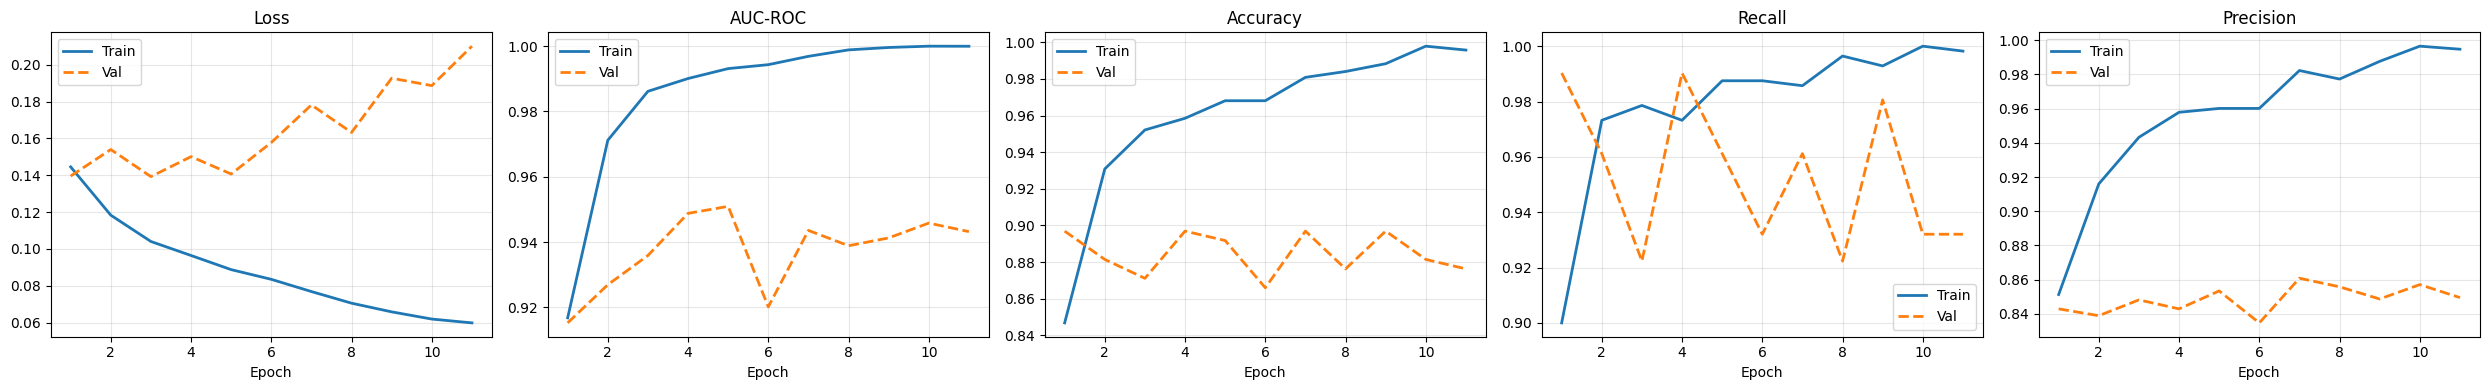

Curves saved → /kaggle/working/runs/training_curves.png


In [14]:
# ── Cell 13 · Training curves + save models ───────────────────────────────────
import json, os
import matplotlib.pyplot as plt

hist_dict = {k: [float(v) for v in vs] for k, vs in history.history.items()}
hist_path = os.path.join(OUTPUT_DIR, 'history.json')
with open(hist_path, 'w') as f:
    json.dump(hist_dict, f, indent=2)
print(f'History saved → {hist_path}')

final_path = os.path.join(OUTPUT_DIR, 'final_model.keras')
model.save(final_path)
print(f'Final model  → {final_path}')
print(f'Best model   → {CHECKPOINT_PATH}')

metric_pairs = [
    ('loss',      'val_loss',      'Loss'),
    ('auc',       'val_auc',       'AUC-ROC'),
    ('accuracy',  'val_accuracy',  'Accuracy'),
    ('recall',    'val_recall',    'Recall'),
    ('precision', 'val_precision', 'Precision'),
]
valid_pairs = [(tr, va, t) for tr, va, t in metric_pairs
               if tr in hist_dict and va in hist_dict]

if valid_pairs:
    fig, axes = plt.subplots(1, len(valid_pairs),
                             figsize=(5 * len(valid_pairs), 4))
    if len(valid_pairs) == 1: axes = [axes]
    for ax, (tr_k, va_k, title) in zip(axes, valid_pairs):
        ep = range(1, len(hist_dict[tr_k]) + 1)
        ax.plot(ep, hist_dict[tr_k], label='Train', lw=2)
        ax.plot(ep, hist_dict[va_k], label='Val',   lw=2, ls='--')
        ax.set_title(title); ax.set_xlabel('Epoch')
        ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    curve_path = os.path.join(OUTPUT_DIR, 'training_curves.png')
    plt.savefig(curve_path, dpi=150); plt.show()
    print(f'Curves saved → {curve_path}')

In [15]:
# ── Cell 14 · Inference on a video file ──────────────────────────────────────
import time, cv2
import numpy as np
from tensorflow.keras.applications.resnet50 import preprocess_input

TEST_VIDEO     = ('/kaggle/input/datasets/daudshah/video-dataset/'
                  'dataset-video-split/test/Assault018_x264.mp4')
SAVE_ANNOTATED = '/kaggle/working/annotated_output.mp4'
CLIP_SECONDS   = 2.0

LABEL_MAP = {0: 'NORMAL', 1: 'SUSPICIOUS'}
COLOR_MAP  = {'NORMAL': (0, 200, 80), 'SUSPICIOUS': (0, 40, 230)}


def predict_clip(frames_bgr):
    processed = []
    for f in frames_bgr:
        f = cv2.cvtColor(f, cv2.COLOR_BGR2RGB)
        f = cv2.resize(f, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        processed.append(f.astype(np.float32) / 255.0)
    while len(processed) < NUM_FRAMES:
        processed.append(processed[-1].copy())
    idx     = np.linspace(0, len(processed)-1, NUM_FRAMES, dtype=int)
    sampled = np.stack([processed[i] for i in idx])
    frames_pp = preprocess_input(sampled * 255.0)
    feats     = feat_extractor.predict(frames_pp, batch_size=NUM_FRAMES, verbose=0)
    feats     = feats[np.newaxis].astype(np.float32)
    prob  = float(model.predict(feats, verbose=0)[0, 0])
    pred  = 1 if prob >= THRESHOLD else 0
    label = LABEL_MAP[pred]
    conf  = prob if pred == 1 else (1.0 - prob)
    return label, conf, prob


def draw_overlay(frame, label, conf, clip_idx):
    out = frame.copy(); h, w = out.shape[:2]
    color = COLOR_MAP[label]; ov = out.copy()
    cv2.rectangle(ov, (0, 0), (w, 52), color, -1)
    cv2.addWeighted(ov, 0.55, out, 0.45, 0, out)
    cv2.putText(out, f'{label}  {conf*100:.1f}%', (12, 34),
                cv2.FONT_HERSHEY_DUPLEX, 1.0, (255,255,255), 2, cv2.LINE_AA)
    cv2.putText(out, f'Clip #{clip_idx}', (w-140, h-12),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (200,200,200), 1, cv2.LINE_AA)
    return out


cap     = cv2.VideoCapture(TEST_VIDEO)
fps_src = cap.get(cv2.CAP_PROP_FPS) or 25.0
total_f = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
W       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H_v     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
clip_len = max(1, int(fps_src * CLIP_SECONDS))

writer = None
if SAVE_ANNOTATED:
    writer = cv2.VideoWriter(SAVE_ANNOTATED, cv2.VideoWriter_fourcc(*'mp4v'),
                             fps_src, (W, H_v))

print(f'Video    : {TEST_VIDEO}')
print(f'Frames   : {total_f}  |  FPS: {fps_src:.1f}  |  Res: {W}×{H_v}')
print(f'Clip len : {clip_len} frames ({CLIP_SECONDS}s) → sampling {NUM_FRAMES} frames')
print(f'Threshold: {THRESHOLD:.3f}')
print(f'\n{"Clip":>5}  {"Time":>16}  {"Label":<12}  {"Conf":>6}  {"P(susp)":>8}  {"ms":>5}')
print('-' * 62)

raw_clip = []; clip_idx = start_fr = cur_fr = 0; results = []
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
while True:
    ret, frame = cap.read()
    if not ret: break
    raw_clip.append(frame); cur_fr += 1
    if len(raw_clip) == clip_len:
        t0 = time.time()
        label, conf, prob = predict_clip(raw_clip)
        ms = (time.time()-t0)*1000
        ts_s, ts_e = start_fr/fps_src, cur_fr/fps_src
        flag = '⚠' if label == 'SUSPICIOUS' else ' '
        print(f'{clip_idx:>5}  [{ts_s:>6.2f}s–{ts_e:>5.2f}s]  '
              f'{flag} {label:<12}  {conf*100:>5.1f}%  '
              f'{prob*100:>7.1f}%  {ms:>4.0f}ms')
        results.append({'clip': clip_idx, 'label': label})
        if writer:
            for fr in raw_clip: writer.write(draw_overlay(fr, label, conf, clip_idx))
        raw_clip = []; start_fr = cur_fr; clip_idx += 1

cap.release()
if writer:
    writer.release()
    print(f'\nAnnotated video → {SAVE_ANNOTATED}')

n_susp = sum(1 for r in results if r['label']=='SUSPICIOUS')
n_norm = len(results) - n_susp
d = max(len(results), 1)
print(f'\n{"-"*50}')
print(f'  Total  : {len(results)}')
print(f'  Normal : {n_norm}  ({n_norm/d*100:.1f}%)')
print(f'  Suspic : {n_susp}  ({n_susp/d*100:.1f}%)')
print(f'{"-"*50}')

Video    : /kaggle/input/datasets/daudshah/video-dataset/dataset-video-split/test/Assault018_x264.mp4
Frames   : 361  |  FPS: 30.0  |  Res: 320×240
Clip len : 60 frames (2.0s) → sampling 16 frames
Threshold: 0.280

 Clip              Time  Label           Conf   P(susp)     ms
--------------------------------------------------------------
    0  [  0.00s– 2.00s]  ⚠ SUSPICIOUS     98.1%     98.1%  3539ms
    1  [  2.00s– 4.00s]  ⚠ SUSPICIOUS     98.2%     98.2%   257ms
    2  [  4.00s– 6.00s]  ⚠ SUSPICIOUS     97.9%     97.9%   253ms
    3  [  6.00s– 8.00s]  ⚠ SUSPICIOUS     97.8%     97.8%   282ms
    4  [  8.00s–10.00s]  ⚠ SUSPICIOUS     97.9%     97.9%   289ms
    5  [ 10.00s–12.00s]  ⚠ SUSPICIOUS     98.0%     98.0%   290ms

Annotated video → /kaggle/working/annotated_output.mp4

--------------------------------------------------
  Total  : 6
  Normal : 0  (0.0%)
  Suspic : 6  (100.0%)
--------------------------------------------------


In [16]:
# ── Cell 15 · (OPTIONAL) Phase 2 — End-to-end fine-tune ─────────────────────
#
# Only run AFTER Phase 1 achieves val_auc > 0.75.
# Unfreezes conv5_block3 (~2 M params) + trained head on raw video frames.
# Set RUN_PHASE2 = True to execute.

import os
RUN_PHASE2    = False
P2_LR         = 3e-6
P2_EPOCHS     = 10
P2_BATCH      = 4
P2_CHECKPOINT = '/kaggle/working/runs/p2_best_model.keras'

if RUN_PHASE2:
    import numpy as np, cv2
    import tensorflow as tf
    from tensorflow.keras import layers, Model, regularizers
    from tensorflow.keras.applications import ResNet50
    from tensorflow.keras.applications.resnet50 import preprocess_input

    class VideoGenerator(tf.keras.utils.Sequence):
        def __init__(self, split_txt, data_root, num_frames, img_size,
                     batch_size, augment=False, shuffle=False, **kwargs):
            super().__init__(**kwargs)
            self.num_frames = num_frames; self.img_size = img_size
            self.batch_size = batch_size; self.augment = augment
            self.shuffle = shuffle
            self.paths, self.labels = load_video_paths_and_labels(split_txt, data_root)
            self.indices = np.arange(len(self.paths))
            if shuffle: np.random.shuffle(self.indices)
            lbl = self.labels
            print(f'  Loaded {len(self.paths)} clips  '
                  f'(normal={(lbl==0).sum()}  suspicious={(lbl==1).sum()})')
        def __len__(self):
            return int(np.ceil(len(self.paths)/self.batch_size))
        def __getitem__(self, bi):
            idxs = self.indices[bi*self.batch_size:(bi+1)*self.batch_size]
            clips, labels = [], []
            for i in idxs:
                frames = load_clip_frames(self.paths[i], self.num_frames, self.img_size)
                if frames is None:
                    frames = np.zeros((self.num_frames, self.img_size, self.img_size, 3), np.float32)
                if self.augment: frames = self._augment(frames)
                clips.append(preprocess_input(frames * 255.0))
                labels.append(self.labels[i])
            return np.stack(clips).astype(np.float32), np.array(labels, np.float32)
        def _augment(self, clip):
            if np.random.rand() < 0.5: clip = clip[:,:,::-1,:]
            delta = np.random.uniform(-0.15, 0.15)
            clip  = np.clip(clip + delta, 0.0, 1.0)
            factor = np.random.uniform(0.85, 1.15)
            mean   = clip.mean()
            return np.clip((clip - mean)*factor + mean, 0.0, 1.0).astype(np.float32)
        def on_epoch_end(self):
            if self.shuffle: np.random.shuffle(self.indices)

    backbone = ResNet50(include_top=False, weights='imagenet',
                        pooling='avg', input_shape=(IMG_SIZE, IMG_SIZE, 3))
    for lyr in backbone.layers: lyr.trainable = False
    for lyr in backbone.layers:
        if (lyr.name.startswith('conv5_block3')
                and not isinstance(lyr, layers.BatchNormalization)):
            lyr.trainable = True

    clip_in     = tf.keras.Input(shape=(NUM_FRAMES, IMG_SIZE, IMG_SIZE, 3), name='clip_input')
    frame_feats = layers.TimeDistributed(backbone, name='td_resnet')(clip_in)
    x = layers.LayerNormalization(name='feat_norm')(frame_feats)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4), name='proj')(x)
    x = layers.Dropout(0.4, name='proj_drop')(x)
    x = layers.Bidirectional(layers.GRU(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1,
                   kernel_regularizer=regularizers.l2(1e-4), recurrent_regularizer=regularizers.l2(1e-5)),
                   name='bigru')(x)
    x = TemporalAttention(name='temporal_attn')(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4), name='head_dense')(x)
    x = layers.Dropout(0.6, name='head_drop')(x)
    out = layers.Dense(1, activation='sigmoid', name='output')(x)
    full_model = Model(inputs=clip_in, outputs=out, name='FullModel')

    phase1_names = {lyr.name for lyr in model.layers}
    for lyr in full_model.layers:
        if lyr.name in phase1_names and lyr.name != 'feature_input':
            try: lyr.set_weights(model.get_layer(lyr.name).get_weights())
            except (ValueError, AttributeError): pass

    n_tr = sum(tf.size(w).numpy() for w in full_model.trainable_weights)
    print(f'Phase 2 trainable params: {n_tr:,}')
    full_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=P2_LR, clipnorm=1.0),
        loss=FocalLoss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA),
        metrics=[tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')],
    )

    p2_train = VideoGenerator(os.path.join(DATA_ROOT,'train.txt'), DATA_ROOT,
                               NUM_FRAMES, IMG_SIZE, P2_BATCH, augment=True,  shuffle=True)
    p2_valid = VideoGenerator(os.path.join(DATA_ROOT,'valid.txt'), DATA_ROOT,
                               NUM_FRAMES, IMG_SIZE, P2_BATCH, augment=False, shuffle=False)

    print('\n' + '='*60)
    print('  PHASE 2 — Fine-tune conv5_block3 + temporal head')
    print('='*60)
    full_model.fit(
        p2_train, validation_data=p2_valid, epochs=P2_EPOCHS,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=5, mode='max',
                                             restore_best_weights=True, verbose=1),
            tf.keras.callbacks.ModelCheckpoint(filepath=P2_CHECKPOINT, monitor='val_auc',
                                              mode='max', save_best_only=True, verbose=1),
        ], verbose=1,
    )
    print(f'\nPhase 2 complete. Best model → {P2_CHECKPOINT}')
else:
    print('Phase 2 skipped (RUN_PHASE2 = False).')
    print('Set RUN_PHASE2 = True once Phase 1 val_auc > 0.75.')

Phase 2 skipped (RUN_PHASE2 = False).
Set RUN_PHASE2 = True once Phase 1 val_auc > 0.75.


In [17]:
# ── Cell 16 · List output files ──────────────────────────────────────────────
import os

print('Output files in /kaggle/working/runs:\n')
for root, dirs, files in os.walk('/kaggle/working/runs'):
    dirs[:] = sorted(d for d in dirs if d != 'logs')
    lvl = root.replace('/kaggle/working/runs', '').count(os.sep)
    print('  '*lvl + os.path.basename(root) + '/')
    for fname in sorted(files):
        size = os.path.getsize(os.path.join(root, fname))
        print('  '*(lvl+1) + f'{fname}  ({size/1e6:.1f} MB)')

print('\nCached features in /kaggle/working/feat_cache:\n')
for fname in sorted(os.listdir(FEAT_CACHE_DIR)):
    size = os.path.getsize(os.path.join(FEAT_CACHE_DIR, fname))
    print(f'  {fname}  ({size/1e6:.1f} MB)')

Output files in /kaggle/working/runs:

runs/
  best_model.keras  (8.0 MB)
  final_model.keras  (8.0 MB)
  history.json  (0.0 MB)
  training_curves.png  (0.2 MB)

Cached features in /kaggle/working/feat_cache:

  test_features.npy  (26.2 MB)
  test_labels.npy  (0.0 MB)
  train_features.npy  (123.2 MB)
  train_labels.npy  (0.0 MB)
  valid_features.npy  (25.4 MB)
  valid_labels.npy  (0.0 MB)


In [18]:
# ── Cell 17 · How to load the saved model in a new session ───────────────────
#
# FIX (new cell): Because TemporalAttention and FocalLoss are custom classes,
# a naive load_model() call fails in v1/v2.  In v3 the @register_keras_serializable
# decorator makes them self-contained, so the simple call works.
#
# ── Standard load (works in v3 because of @register_keras_serializable) ──────
#
#   import tensorflow as tf
#
#   model = tf.keras.models.load_model('/kaggle/working/runs/best_model.keras')
#   # That's it — no custom_objects needed.
#
# ── Fallback if running v2 weights with v3 code ──────────────────────────────
# If you have weights from v2 (saved WITHOUT the decorator), you must define
# both classes first (Cells 8 & 9), then load with explicit custom_objects:
#
#   model = tf.keras.models.load_model(
#       '/kaggle/working/runs/best_model.keras',
#       custom_objects={
#           'TemporalAttention': TemporalAttention,
#           'FocalLoss':         FocalLoss,
#       }
#   )
#
# ── Quick sanity check after loading ─────────────────────────────────────────
import numpy as np, tensorflow as tf

loaded = tf.keras.models.load_model(CHECKPOINT_PATH)
print(f'Loaded: {loaded.name}  |  params: {loaded.count_params():,}')

# Run one test prediction to confirm the model is functional
sample = test_feats[:1].astype(np.float32)
prob   = float(loaded.predict(sample, verbose=0)[0, 0])
pred   = 'SUSPICIOUS' if prob >= THRESHOLD else 'NORMAL'
print(f'Sample prediction: {pred}  (p={prob:.4f}, threshold={THRESHOLD:.3f})')
print('\nModel loads and predicts correctly ✓')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'temporal_attn', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Loaded: TemporalHead  |  params: 660,738
Sample prediction: SUSPICIOUS  (p=0.8822, threshold=0.280)

Model loads and predicts correctly ✓
